<a href="https://colab.research.google.com/github/guedes87/ciencia-de-dados-e-analytics-PUCRIO/blob/main/análise%20de%20Dados/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise de Dados e Boas Práticas

**Nome:** Thiago Rodrigues  Guedes da Silva

**Matrícula:** 4052025000113

**Dataset:** [Diabetes 130 Dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)


# Descrição do Problema

O conjunto de dados representa dez anos (1999-2008) de atendimento clínico em 130 hospitais dos EUA e redes de distribuição integradas. Cada linha diz respeito aos registros hospitalares de pacientes diagnosticados com diabetes, que foram submetidos a exames laboratoriais, medicamentos e permaneceram internados por até 14 dias. O objetivo principal é analisar os dados relacionados a diabetes, comparando com: gênero, faixa de idade, raça/cor, exames laboratoriais e tempo de internação.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

- Qual dos dois gêneros é mais propenso prescrição de medicamentos para diabetes?

- Em qual faixa de idade teve o maior número de prescrições?

- A Raça/cor tem influência nas prescrições?

- Qual o tempo médio de internação?

- Qual as especialidades médicas mais procuradas?

- Qual gênero procura mais o serviço de emergência?

## Atributos do Dataset

O dataset Diabetes 130 contém 101766 amostras com 50 atributos.
Os atributo explorados são::




- ***patient_nbr***(Identificador único de um paciente)
- ***race*** (Raça/cor)
- ***gender*** (Gênero)
- ***age*** (Idade)
- ***time_in_hospital*** (Tempo de internação)
- ***num_lab_procedures*** (Número de exames laboratoriais realizados durante o encontro)
- ***number_emergency***(Número de atendimentos de emergência do paciente no ano anterior ao atendimento)
- ***diabetesMed***(Indica se foi prescrito algum medicamento para diabetes.)
- ***medical_specialty*** (Especialidade Médica)



# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [ ]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Importação de pacotes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import missingno as ms # para tratamento de missings
## Transformações Numéricas
from sklearn.preprocessing import MinMaxScaler # para normalização
from sklearn.preprocessing import StandardScaler # para padronização
## Transformações Categóricas
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

#Carga do Dataset



In [ ]:
# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/guedes87/ciencia-de-dados-e-analytics-PUCRIO/refs/heads/main/an%C3%A1lise%20de%20Dados/diabetic_data.csv"

# Lê o arquivo
dataset = pd.read_csv(url, delimiter=',')



##Visualização das primeiras linhas

Existem dados faltantes, porém representados como '?'e não NaN(dado nulos)

In [ ]:
#Exibe as primeiras linhas
dataset.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


##Informações Gerais do dataset

Podemos observar que temos 50 atributos com 101.766 linhas. No segundo painel de informações, possui todos os atributos descritos, com as informções do tipo do dado e se existe algum dado faltante.

In [ ]:
# Mostra as dimensões do dataset
dataset.shape

(101766, 50)

In [ ]:
# Mostra as informações do dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
#TESTE de NULL
dataset.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


#Cópia do Dataset para manipulação

Foi realizado uma copia do dataset, para manter os dados originais e aplicar as modificações na cópia.
Alteração do valor das celulas atribuidas com '?' para NaN.
Teste de nulidade com a visaulização matricial.

<Axes: >

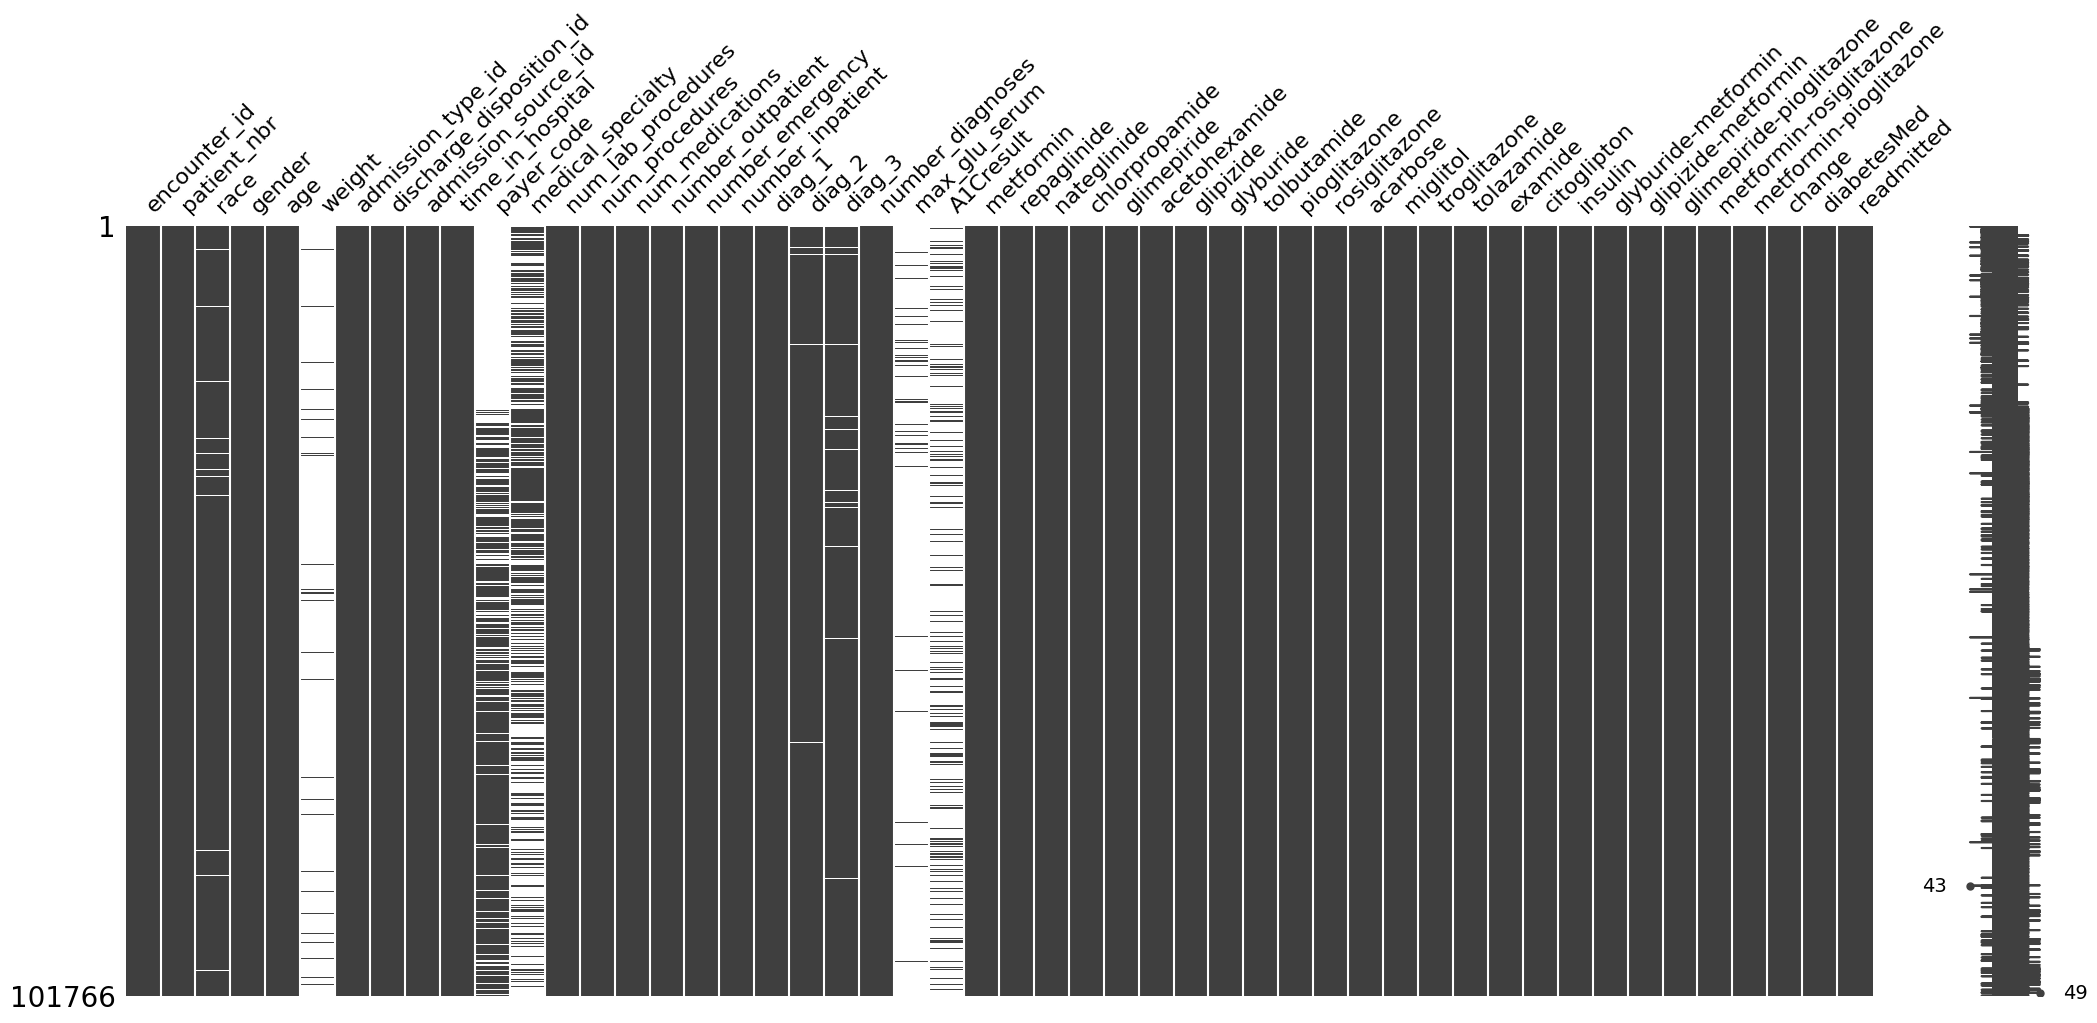

In [ ]:
# salvando um novo dataset para tratamento de missings
copy = list (dataset.columns)

# o novo dataset irá conter todas as colunas do dataset original
dataset_copy = dataset[copy[:]]

# substituindo os ? por NaN
# Foi verificado que as células em branco foram preenchidas com '?'.
dataset_copy.replace('?', np.nan, inplace=True)

# exibindo visualização matricial da nulidade do dataset
ms.matrix(dataset_copy)

In [ ]:
# verificando novamente nulls no dataset
dataset_copy.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


## Seleção dos atributos

Seleção dos atributos mais relevantes para o treinamento.

<Axes: >

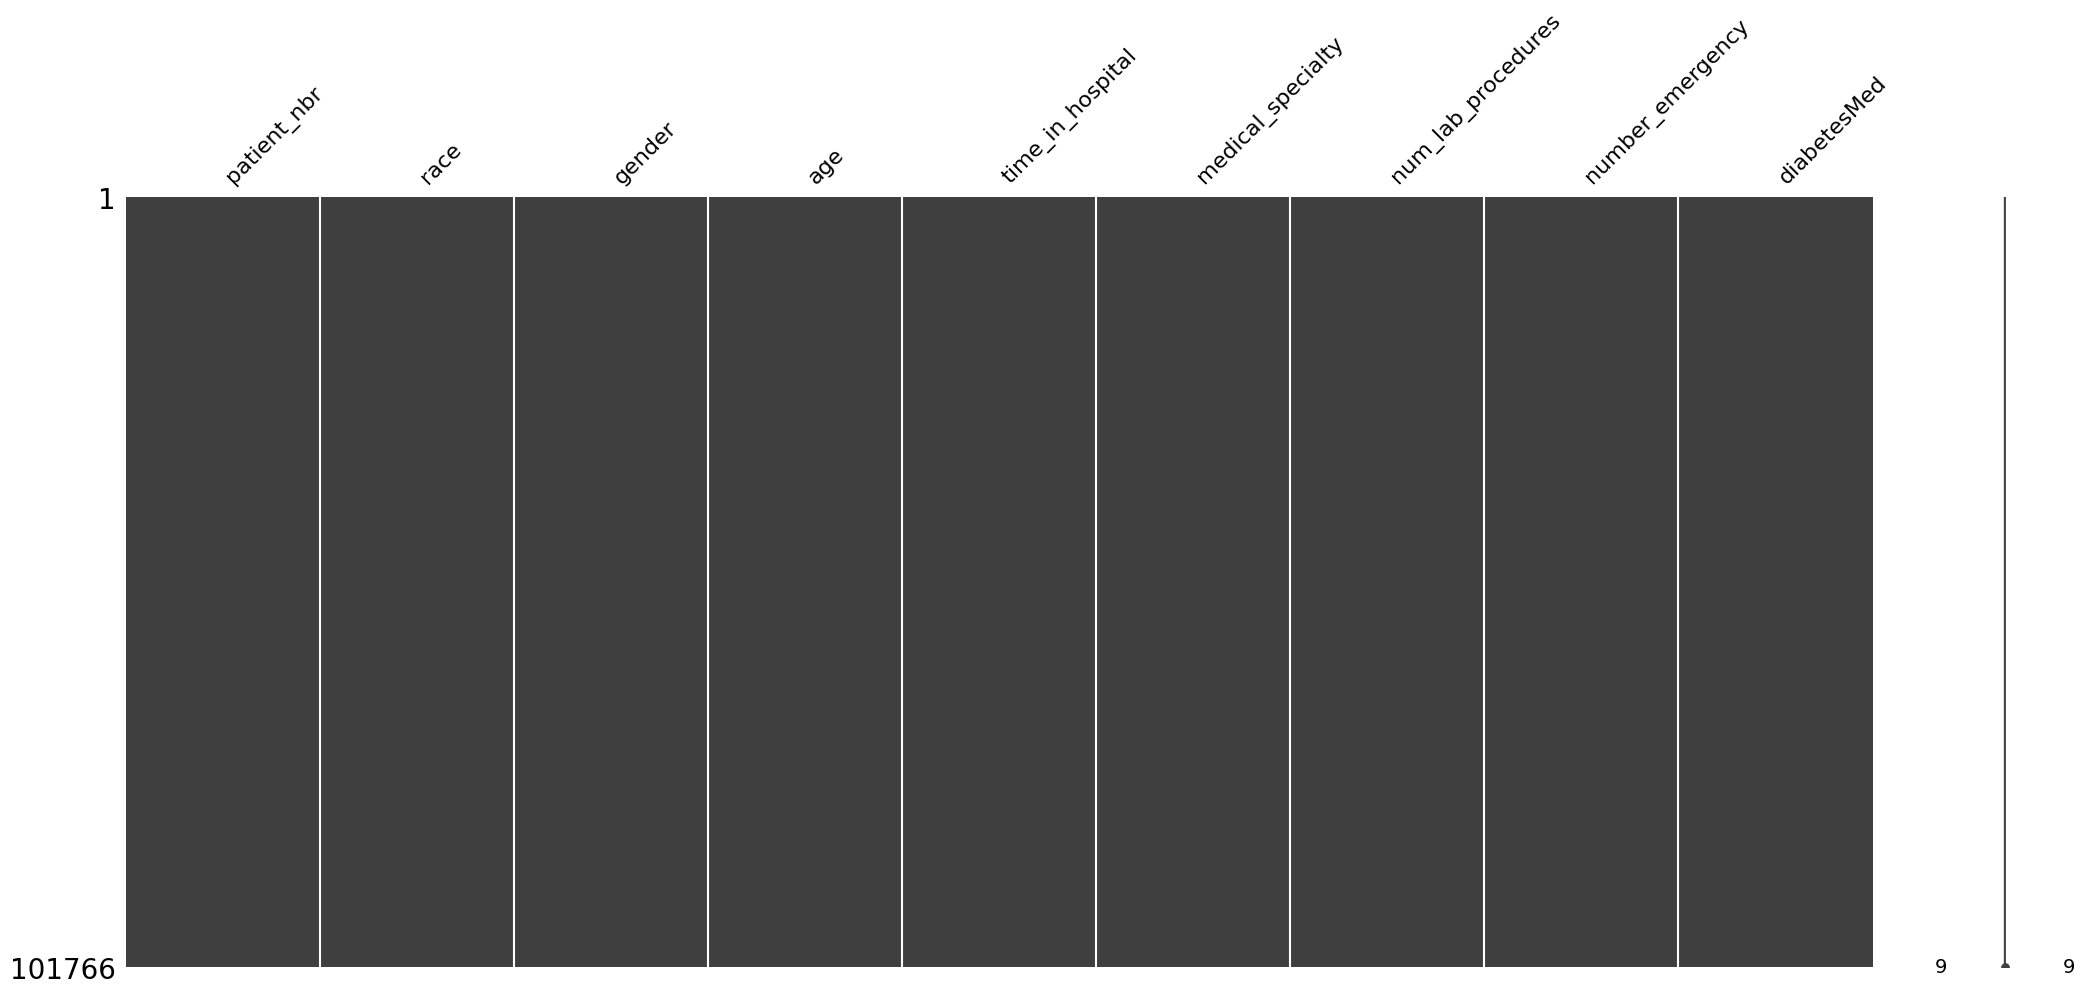

In [ ]:
# selecionar somente as colunas com o
dataset_copy = dataset_copy[['patient_nbr','race', 'gender', 'age', 'time_in_hospital', 'medical_specialty','num_lab_procedures', 'number_emergency','diabetesMed']]

# exibindo visualização matricial da nulidade do dataset
ms.matrix(dataset_copy)

##Padronização dos dados faltantes

In [ ]:
# prompt: trocar o valor da coluna 'medical_specialty' de 'NaN' para 'Not informed'

dataset_copy['medical_specialty'].fillna('Not informed', inplace=True)
dataset_copy['race'].fillna('Not informed', inplace=True)


#Mostra valores NaN
print(dataset_copy.isnull().sum())



patient_nbr           0
race                  0
gender                0
age                   0
time_in_hospital      0
medical_specialty     0
num_lab_procedures    0
number_emergency      0
diabetesMed           0
dtype: int64


## Imprime dados padronizados

In [ ]:
#Imprime as 5 primeiras linhas
dataset_copy.head(5)


,patient_nbr,race,gender,age,time_in_hospital,medical_specialty,num_lab_procedures,number_emergency,diabetesMed
0,8222157,Caucasian,Female,[0-10),1,Pediatrics-Endocrinology,41,0,No
1,55629189,Caucasian,Female,[10-20),3,Not informed,59,0,Yes
2,86047875,AfricanAmerican,Female,[20-30),2,Not informed,11,0,Yes
3,82442376,Caucasian,Male,[30-40),2,Not informed,44,0,Yes
4,42519267,Caucasian,Male,[40-50),1,Not informed,51,0,Yes


## Visualização matricial da nulidade do dataset

<Axes: >

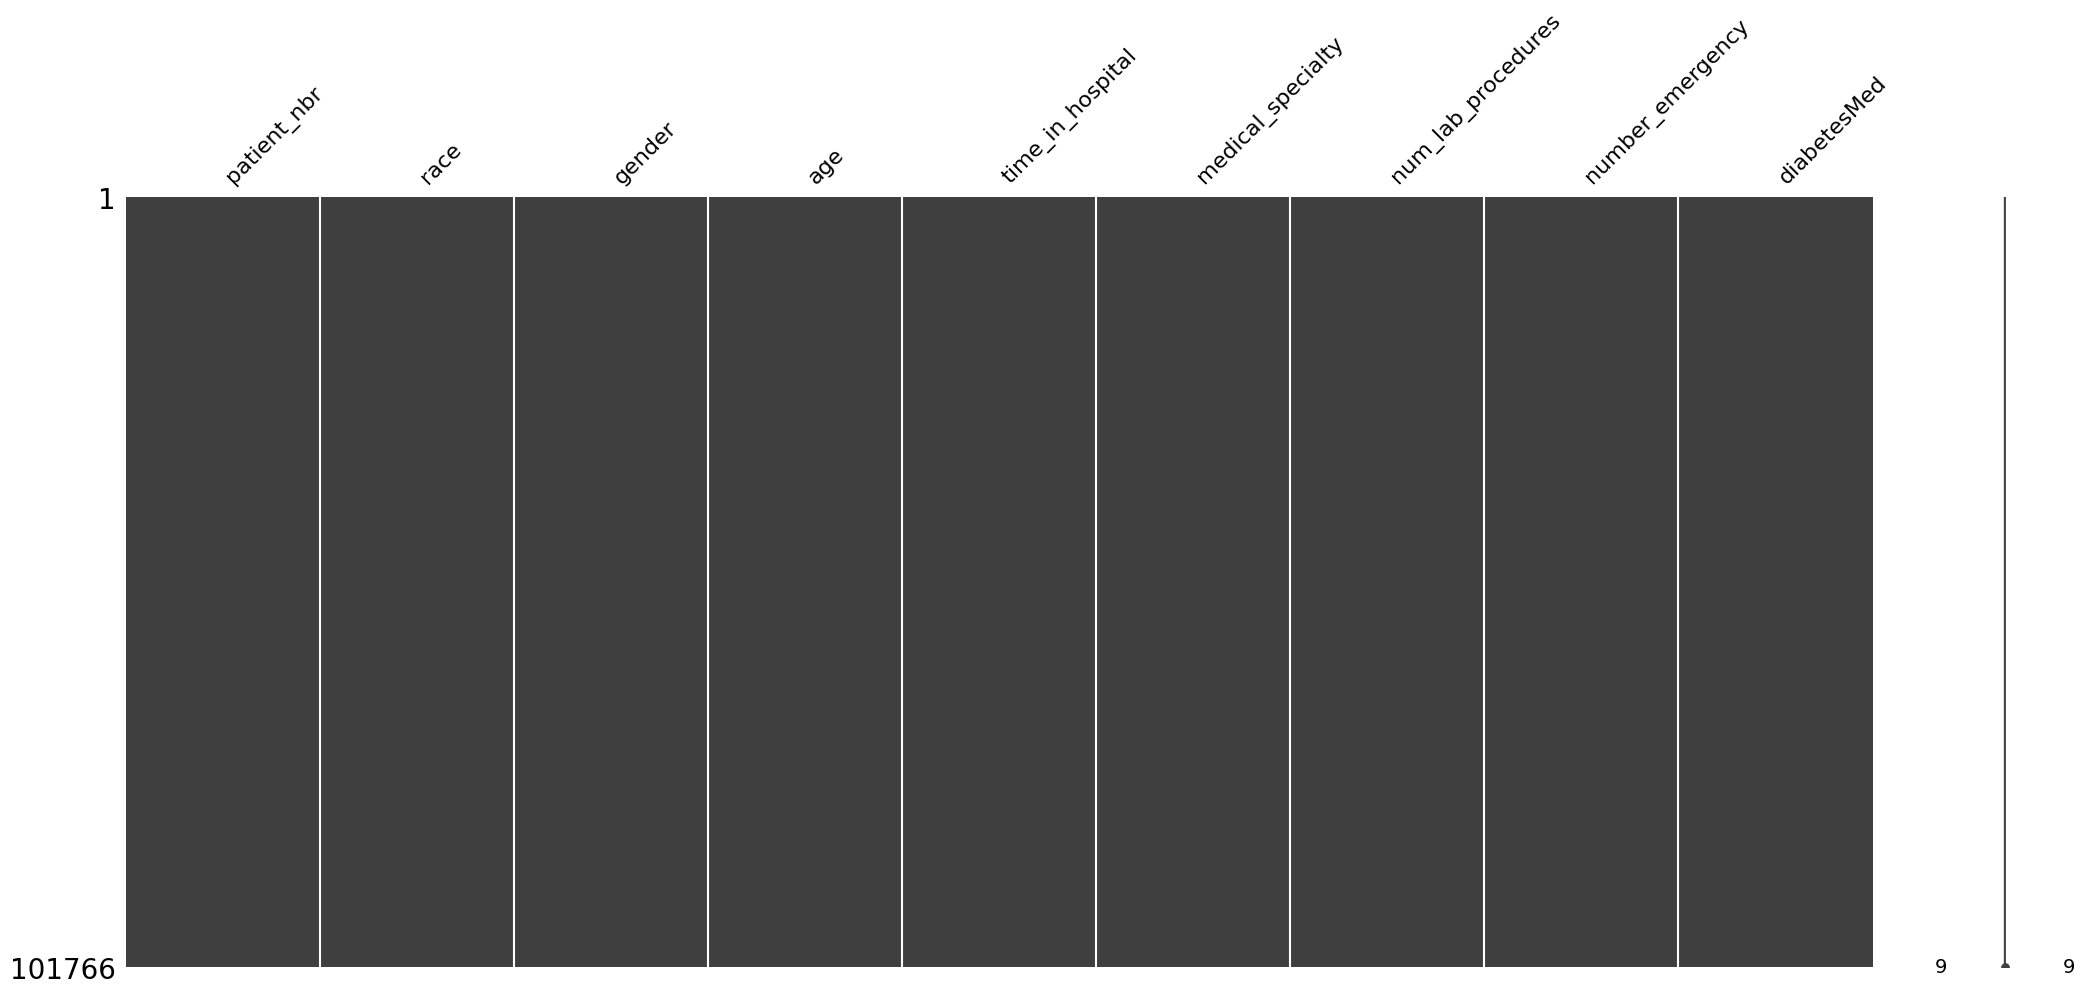

In [ ]:
# exibindo visualização matricial da nulidade do dataset
ms.matrix(dataset_copy)

# Análise do Dataset

## Distribuição dos dados

Os dados apresentam uma visão geral da demografia dos pacientes, focando nas características de gênero, idade e raça.



In [ ]:
#Calcula e apresenta a distribuição dos valores das colunas: Gênero, Raça/Cor e Idade

def consulta_distribution_to_markdown(dataframe, column_name):

  #Teste se a coluna existe no dataset
  if column_name not in dataframe.columns:
    return f"Coluna '{column_name}' não encontrada no DataFrame."

  distribution = dataframe[column_name].value_counts(dropna=False).reset_index()
  distribution.columns = [column_name, 'número de pacientes']
  distribution['% porcentagem'] = (distribution['número de pacientes'] / len(dataframe) * 100).round(2)
  print('\n')

#Mostra o nome de cada tabela
  markdown_table = f"### Distribuição da coluna '{column_name}'\n\n"
  markdown_table += distribution.to_markdown(index=False)

  return markdown_table

#Excluir o Unknown/Invalid do gênero
#dataset_copy = dataset_copy[dataset_copy['gender'] != 'Unknown/Invalid'].copy()

# Colunas do dataset
print(consulta_distribution_to_markdown(dataset_copy, 'gender')) #Gênero
print(consulta_distribution_to_markdown(dataset_copy, 'age')) #Idade
print(consulta_distribution_to_markdown(dataset_copy, 'race')) #Raça/cor




### Distribuição da coluna 'gender'

| gender          |   número de pacientes |   % porcentagem |
|:----------------|----------------------:|----------------:|
| Female          |                 54708 |           53.76 |
| Male            |                 47055 |           46.24 |
| Unknown/Invalid |                     3 |            0    |


### Distribuição da coluna 'age'

| age      |   número de pacientes |   % porcentagem |
|:---------|----------------------:|----------------:|
| [70-80)  |                 26068 |           25.62 |
| [60-70)  |                 22483 |           22.09 |
| [50-60)  |                 17256 |           16.96 |
| [80-90)  |                 17197 |           16.9  |
| [40-50)  |                  9685 |            9.52 |
| [30-40)  |                  3775 |            3.71 |
| [90-100) |                  2793 |            2.74 |
| [20-30)  |                  1657 |            1.63 |
| [10-20)  |                   691 |            0.68 |
| [0-10)  

**Gênero**

A distribuição por gênero mostra uma leve predominância feminina, representando 53,76% dos pacientes, enquanto os pacientes do sexo masculino correspondem a 46,24%. Um número muito pequeno de registros (3) foi classificado como "Unknown/Invalid", o que é insignificante para a análise geral.

**Idade**

A faixa etária com a maior concentração de pacientes é [70-80), representando 25,62% do total. As faixas subsequentes mais representativas são [60-70) com 22,09% e [50-60) com 16,96%. É evidente que a maioria dos pacientes se encontra em faixas etárias mais elevadas, com aproximadamente 81,57% dos pacientes acima dos 50 anos. As faixas mais jovens, especialmente [0-10) e [10-20), apresentam as menores porcentagens.

**Raça**

Em relação à raça, a categoria "Caucasian" é dominante, compreendendo 74,78% dos pacientes. Em segundo lugar, com uma parcela significativamente menor, estão os "AfricanAmerican" com 18,88%. Outras categorias raciais, como "Hispanic", "Other" e "Asian", representam porcentagens muito pequenas do total. Há também uma parcela de dados "Not informed" com 2,23%, que pode indicar a necessidade de melhorar a coleta dessas informações.

Em resumo, a população de pacientes tende a ser predominantemente feminina, mais velha (acima de 50 anos) e majoritariamente caucasiana.

In [ ]:
# Conta a quantidade de consultas por paciente
consultas_por_paciente = dataset_copy['patient_nbr'].value_counts().reset_index()
consultas_por_paciente.columns = ['patient_nbr', 'numero de consultas']

# Conta quantas vezes cada número de consulta aparece
contagem_numero_consultas = consultas_por_paciente['numero de consultas'].value_counts().sort_index().reset_index()
contagem_numero_consultas.columns = ['número de consultas', 'número de pacientes']
contagem_numero_consultas['% porcentagem'] = (contagem_numero_consultas['número de pacientes'] / contagem_numero_consultas['número de pacientes'].sum() * 100).round(2)
print(contagem_numero_consultas.to_markdown(index=False))



|   número de consultas |   número de pacientes |   % porcentagem |
|----------------------:|----------------------:|----------------:|
|                     1 |                 54745 |           76.55 |
|                     2 |                 10434 |           14.59 |
|                     3 |                  3328 |            4.65 |
|                     4 |                  1421 |            1.99 |
|                     5 |                   717 |            1    |
|                     6 |                   346 |            0.48 |
|                     7 |                   207 |            0.29 |
|                     8 |                   111 |            0.16 |
|                     9 |                    70 |            0.1  |
|                    10 |                    42 |            0.06 |
|                    11 |                    20 |            0.03 |
|                    12 |                    19 |            0.03 |
|                    13 |                    14 

A frequência de consultas por paciente, mostra um padrão claro de que a grande maioria dos pacientes realiza poucas consultas.

Com 76,55% dos pacientes (54.745 indivíduos) tiveram apenas uma consulta. Esse é o grupo mais significativo, dominando amplamente a distribuição. Pacientes com duas consultas representam o segundo maior grupo, com 14,59%.

À medida que o número de consultas aumenta, a porcentagem de pacientes diminui drasticamente. Por exemplo, apenas 4,65% dos pacientes tiveram três consultas e esse número cai para menos de 1% para cinco consultas ou mais. Casos de consultas acima de 10 são extremamente raros, com a maioria dessas categorias representando 0,01% ou 0% dos pacientes, indicando que poucos indivíduos realizam um grande volume de atendimentos.

Em resumo, a análise demonstra que a base de dados é composta majoritariamente por pacientes que tiveram uma ou duas consultas, com uma pequena parcela de pacientes realizando múltiplas consultas.

## Gráficos da distribuição



### Distribuição da coluna 'race'

| race            |   número de pacientes |   % porcentagem |
|:----------------|----------------------:|----------------:|
| Caucasian       |                 76099 |           74.78 |
| AfricanAmerican |                 19210 |           18.88 |
| Not informed    |                  2273 |            2.23 |
| Hispanic        |                  2037 |            2    |
| Other           |                  1506 |            1.48 |
| Asian           |                   641 |            0.63 |





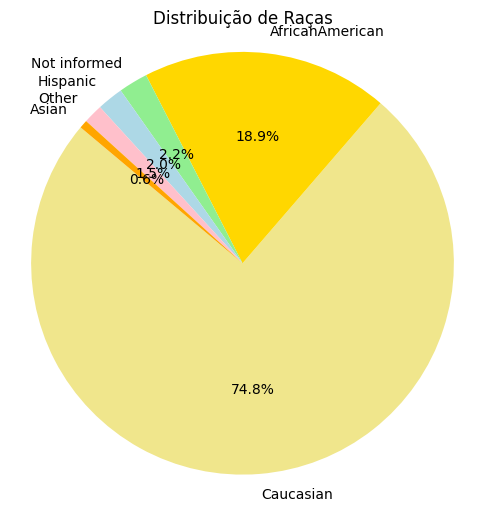

In [ ]:
# Grfico da distribuição ddos Gêneros

plt.figure(figsize=(6, 6)) # Ajuste o tamanho para um único gráfico
# Gráfico de Pizza para Distribuição de Raças
# Defina as cores para as fatias do gráfico de raça
colors_race = ['khaki', 'gold', 'lightgreen', 'lightblue', 'pink', 'orange'] # Exemplo de cores
race_counts = dataset_copy['race'].value_counts()
plt.pie(race_counts, labels=race_counts.index, autopct='%1.1f%%', startangle=140, colors=colors_race)
plt.title('Distribuição de Raças')
plt.axis('equal')

print(consulta_distribution_to_markdown(dataset_copy, 'race')) #Raça/cor
print('\n\n')
plt.show()



### Distribuição da coluna 'gender'

| gender          |   número de pacientes |   % porcentagem |
|:----------------|----------------------:|----------------:|
| Female          |                 54708 |           53.76 |
| Male            |                 47055 |           46.24 |
| Unknown/Invalid |                     3 |            0    |





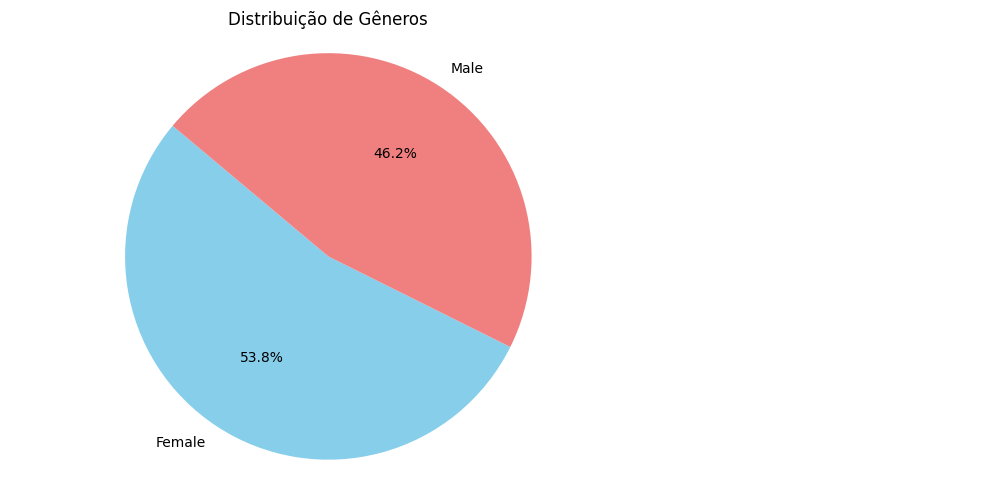

In [ ]:

# Gráfico de Pizza para a Distribuição de Gêneros (excluindo 'Invalid')

# Filtrar os dados para incluir apenas 'Male' e 'Female'
gender_data = dataset_copy[dataset_copy['gender'].isin(['Male', 'Female'])].copy()

# Contar a frequência de cada gênero válido
contagem_genero = gender_data['gender'].value_counts()

# Criar a figura e os eixos para o gráfico e a tabela
fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 0.5]}) # Ajuste a largura para ter espaço para a tabela

# Gráfico de Pizza
wedges, texts, autotexts = ax[0].pie(contagem_genero, labels=contagem_genero.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
ax[0].set_title('Distribuição de Gêneros')
ax[0].axis('equal')  # Garante que o gráfico de pizza seja um círculo.

# Tabela com os números totais de cada gênero
# Criar um DataFrame para a tabela
#table_data = pd.DataFrame({'Gênero': contagem_genero.index, 'Número Total': contagem_genero.values})

# Adicionar a tabela ao lado direito do gráfico
#table = ax[1].table(cellText=table_data.values,
                     #colLabels=table_data.columns,
                     #cellLoc='center',
                     #loc='center') # Localização da tabela no segundo subplot

# Configurações da tabela
#table.auto_set_font_size(False)
#table.set_fontsize(10)
#table.scale(1.2, 1.2) # Ajuste o tamanho da tabela

# Remover os eixos do segundo subplot para que apenas a tabela seja visível
ax[1].axis('off')

plt.tight_layout() # Ajusta o layout para evitar sobreposição

print(consulta_distribution_to_markdown(dataset_copy, 'gender')) #Gênero
print('\n\n')

plt.show()


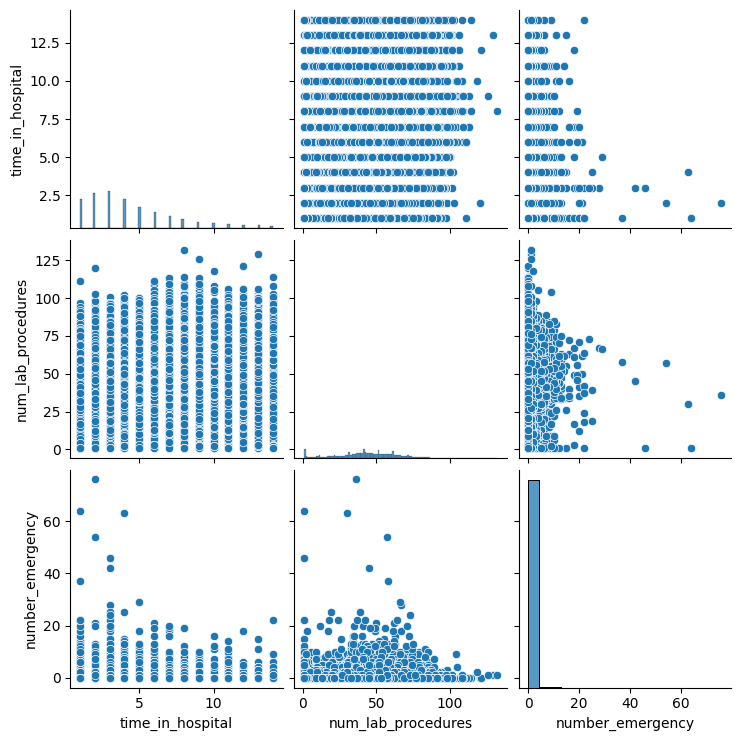

In [ ]:
# Scatter Plot com dataset
sns.pairplot(dataset_copy)

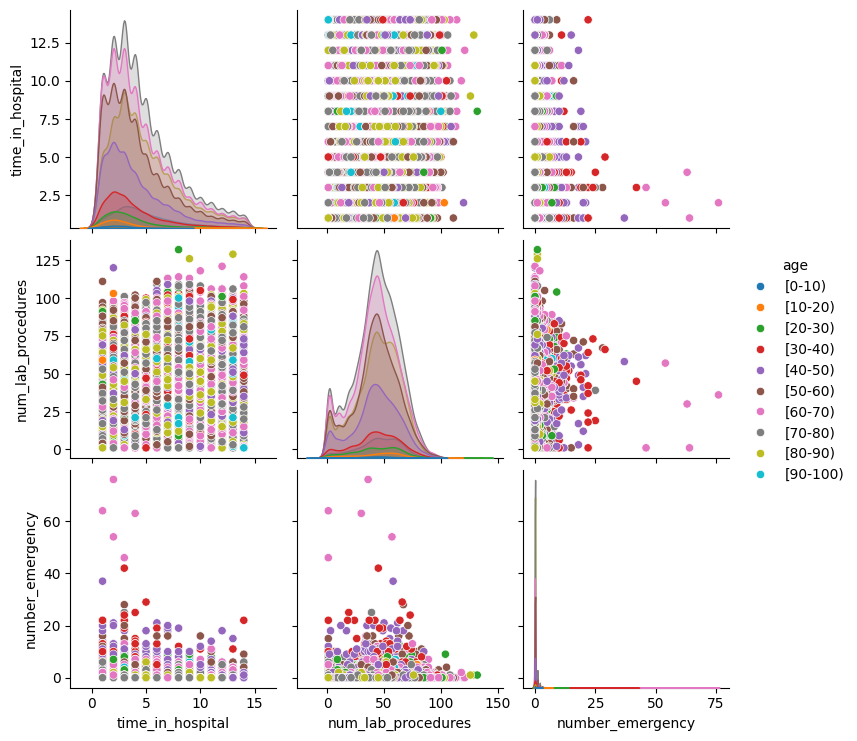

In [ ]:
# Scatter Plot com a idade
sns.pairplot(dataset_copy, hue = "age", height = 2.5);

Distribuição do dataset com o gráfico de dispersão

## Média de consulta por faixa de idade

O gráfico representa a média de consultas por faixa etária, como visto na distribuição dos dados anteriormente, a faixa etária: [60 e 70] e
[70 a 80] cada uma representam 25% da quantidade de consultas totais, refletindo na média de consulta.





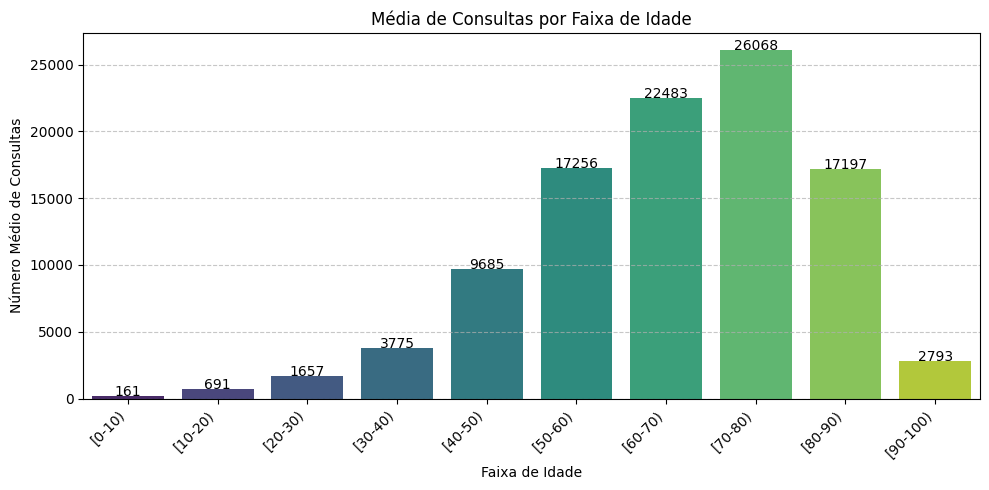

| idade    |   número de consultas |
|:---------|----------------------:|
| [0-10)   |                   161 |
| [10-20)  |                   691 |
| [20-30)  |                  1657 |
| [30-40)  |                  3775 |
| [40-50)  |                  9685 |
| [50-60)  |                 17256 |
| [60-70)  |                 22483 |
| [70-80)  |                 26068 |
| [80-90)  |                 17197 |
| [90-100) |                  2793 |


In [ ]:
#Gráfico com a média de consultas por idade

# Calcular o número médio de consultas por faixa de idade

consultas_por_idade = dataset_copy.groupby('age')['patient_nbr'].count().reset_index()
consultas_por_idade.columns = ['idade', 'número de consultas']

# Classificar por idade
consultas_por_idade['idade_order'] = consultas_por_idade['idade'].apply(lambda x: int(x.split('-')[0].replace('[','')))
consultas_por_idade = consultas_por_idade.sort_values('idade_order').drop('idade_order', axis=1)

# Configuração do gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x='idade', y='número de consultas', data=consultas_por_idade, palette='viridis')
plt.title('Média de Consultas por Faixa de Idade')
plt.xlabel('Faixa de Idade')
plt.ylabel('Número Médio de Consultas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

def is_not_prime(n):
    result = False
    for i in range(2,int(math.sqrt(n)) + 1):
        if n % i == 0:
            result = True
    return result

# Adicionar os valores do número de consultas em cada barra do gráfico
for index, row in consultas_por_idade.iterrows():
    plt.text(index, row['número de consultas'], round(row['número de consultas'], 2), color='black', ha="center")
plt.show()

print(consultas_por_idade.to_markdown(index=False)) # Dados tabulados


Os dados demonstram uma clara correlação entre a idade e o número médio de consultas, com as faixas etárias mais avançadas registrando um volume significativamente maior de atendimentos.

A maioria das consultas está concentrada em pacientes idosos, especialmente nas faixas etárias de [70-80), com 26.068 consultas, e [60-70), com 22.483 consultas. Juntas, essas duas faixas representam a maior média dos atendimentos. A faixa [50-60) também apresenta um número considerável, com 17.256 consultas, reforçando a tendência de que quanto mais velha a pessoa, maior a demanda por serviços de saúde.

Em contraste, as faixas etárias mais jovens, de [0-10) a [30-40), têm a média de consultas progressivamente menor. A faixa [0-10), por exemplo, registrou apenas 161 consultas, a menor média entre todas as categorias. Isso sugere que a necessidade de cuidados médicos diretos, conforme medido pela média de consultas, aumenta consideravelmente com a idade.

Em resumo, a distribuição indica que o sistema de saúde atende majoritariamente a população mais velha, que é a que mais busca ou necessita de consultas médicas.

## Prescrição de Medicamentos para Diabetes



###Pacientes por Raça/Cor

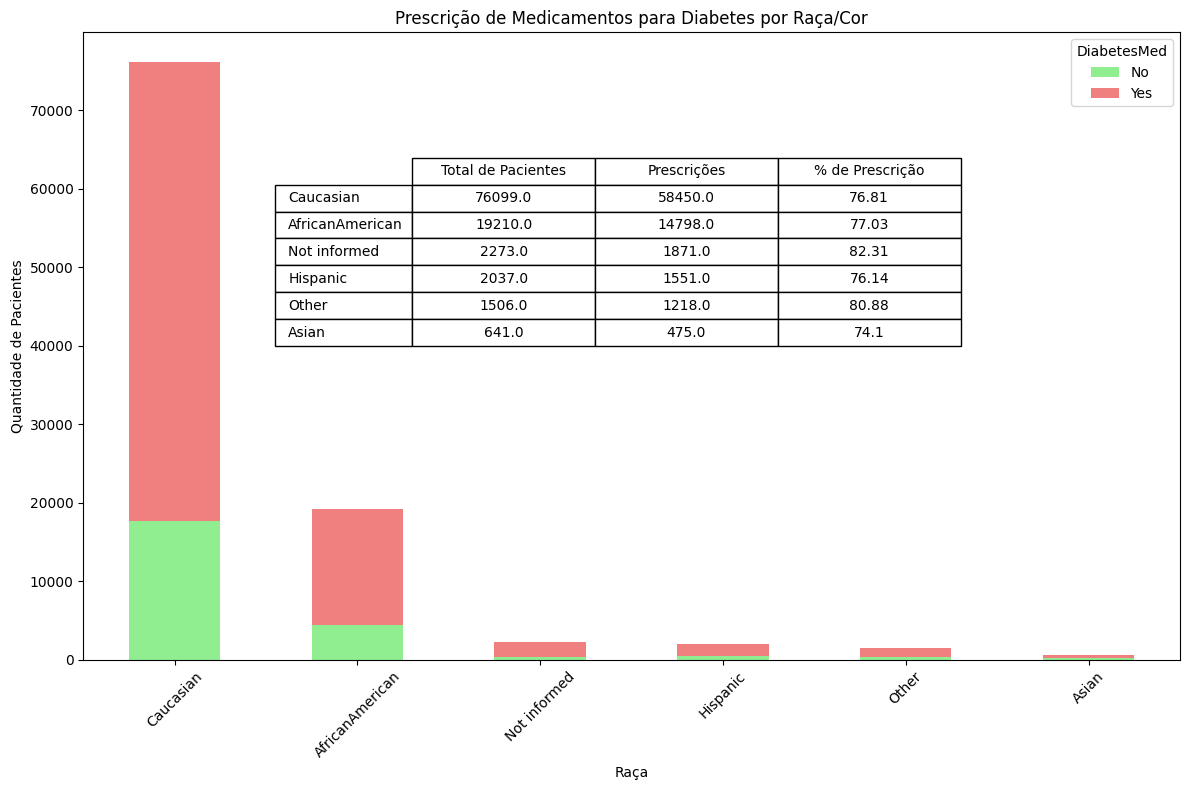

In [ ]:

# Filtra os dados para incluir apenas as linhas onde 'diabetesMed' é 'Yes'
df_diabetic = dataset_copy[dataset_copy['diabetesMed'] == 'Yes'].copy()

# Contabiliza o número de diabéticos por raça
diabetic_counts = df_diabetic['race'].value_counts()

# Contabiliza o número total de pacientes por raça
total_counts = dataset_copy['race'].value_counts()

# Calcula a porcentagem de diabéticos em cada raça
percentage_diabetic = (diabetic_counts / total_counts * 100).fillna(0).sort_values(ascending=False)

# Junta as contagens de diabéticos e não diabéticos por raça
stacked_data = dataset_copy.groupby(['race', 'diabetesMed']).size().unstack(fill_value=0)
stacked_data = stacked_data.sort_values(by='Yes', ascending=False)

# Cria a figura e os eixos do gráfico
fig, ax = plt.subplots(figsize=(12, 8))

# Cria o gráfico de barras empilhadas
stacked_data.plot(kind='bar', stacked=True, ax=ax, color=['lightgreen', 'lightcoral'])

# Adiciona os rótulos e título
ax.set_xlabel('Raça')
ax.set_ylabel('Quantidade de Pacientes')
ax.set_title('Prescrição de Medicamentos para Diabetes por Raça/Cor')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='DiabetesMed')

# Cria a tabela com as porcentagens
table_data = pd.DataFrame({
    'Total de Pacientes': total_counts,
    'Prescrições': diabetic_counts,
    '% de Prescrição': percentage_diabetic.round(2)
}).loc[stacked_data.index] # Garante que a ordem da tabela seja a mesma do gráfico

# Adiciona a tabela no gráfico
table = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 rowLabels=table_data.index,
                 cellLoc = 'center',
                 loc='center',
                 bbox=[0.3, 0.5, 0.5, 0.3]) # Ajuste a posição e tamanho da tabela conforme necessário

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.2)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()

#print(stacked_data.to_markdown())

# Exibe o gráfico
plt.show()

**Análise da Prescrição de Medicamentos para Diabetes por Raça**

Para a raça **Caucasiana**, que é a mais representativa na base de dados, 58.450 pacientes (76.81%) receberam prescrição de medicamentos para diabetes, em contraste com 17.649 que não receberam. Essa proporção se repete nas demais raças:

**AfricanAmerican:** 14.798 pacientes com prescrição versus 4.412 sem.

**Not informed:** 1.871 pacientes com prescrição versus 402 sem.

**Hispanic:** 1.551 pacientes com prescrição versus 486 sem.

**Other:** 1.218 pacientes com prescrição versus 288 sem.

**Asian:** 475 pacientes com prescrição versus 166 sem.

Essa distribuição sugere que, na população estudada, há uma prevalência de prescrição de medicamentos para diabetes em todos os grupos raciais,

### Pacientes por Faixa de Idade

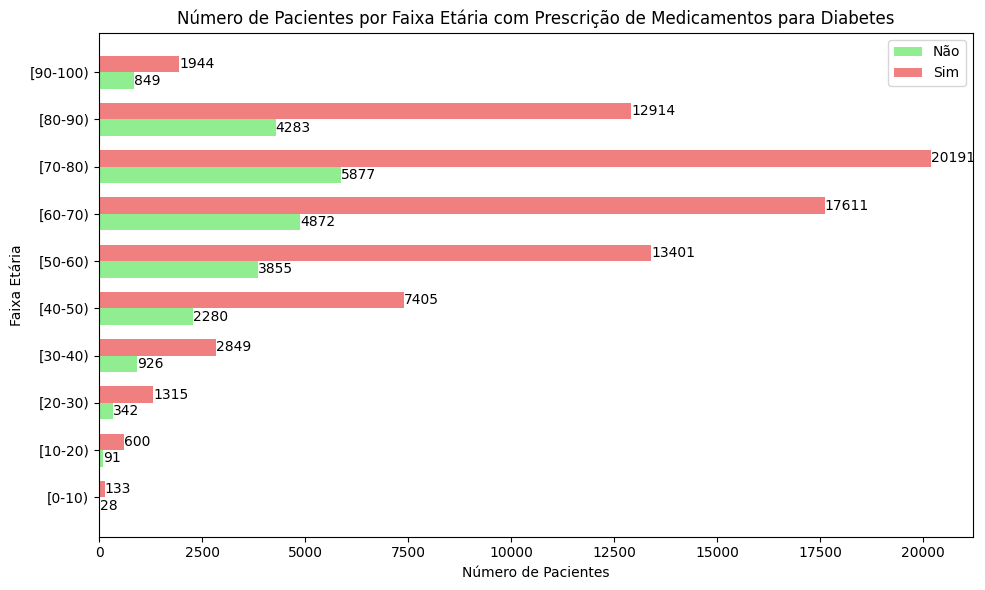

In [ ]:

# Calcula a contagem de pacientes com diabetesMed por faixa etária
diabetes_Idade = dataset_copy.groupby('age')['diabetesMed'].value_counts().unstack().fillna(0)

# Renomeia as colunas para clareza
diabetes_Idade = diabetes_Idade.rename(columns={'No': 'No DiabetesMed', 'Yes': 'DiabetesMed'})

# Ordena as faixas etárias, assumindo que estão em ordem alfabética (pode ser necessário ajustar se a ordem não for numérica)
diabetes_Idade = diabetes_Idade.sort_index()

# Cria o gráfico de barras horizontal duplo
fig, ax = plt.subplots(figsize=(10, 6))

# Largura da barra
bar_height = 0.35
index = np.arange(len(diabetes_Idade.index))

# Barras para 'No DiabetesMed'
bars1 = ax.barh(index, diabetes_Idade['No DiabetesMed'], bar_height, label='Não', color='lightgreen')

# Barras para 'DiabetesMed'
bars2 = ax.barh(index + bar_height, diabetes_Idade['DiabetesMed'], bar_height, label='Sim', color='lightcoral')

# Configurações do eixo Y
ax.set_yticks(index + bar_height / 2)
ax.set_yticklabels(diabetes_Idade.index)
ax.set_xlabel('Número de Pacientes')
ax.set_ylabel('Faixa Etária')
ax.set_title('Número de Pacientes por Faixa Etária com Prescrição de Medicamentos para Diabetes')
ax.legend()

# Adiciona os valores no final das barras
def add_value_labels(ax, bars):
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
                f'{int(width)}',
                va='center')

add_value_labels(ax, bars1)
add_value_labels(ax, bars2)

plt.tight_layout()
#print(diabetes_Idade.to_markdown())
plt.show()

**Maior incidência de prescrição em faixas etárias mais velhas:**

As faixas etárias mais avançadas ([60-70), [70-80), [80-90)) são as que mais recebem medicamentos para diabetes.

A faixa [70-80) lidera, com 20.191 pacientes recebendo medicamentos, em comparação com 5.877 que não.

Em seguida, a faixa [60-70), com 17.611 pacientes medicados e 4.872 sem.
Pacientes entre [50-60) também mostram um alto número de prescrições, totalizando 13.401.

**Menor incidência de prescrição em faixas etárias mais jovens:**

Conforme a idade diminui, o número de pacientes que recebem medicamentos para diabetes reduz drasticamente.

Na faixa [0-10), apenas 133 pacientes recebem medicação, enquanto 28 não.

A faixa [10-20) mostra 600 pacientes medicados, contra 91 sem.


Existe um padrão consistente em todas as faixas etárias é que o número de pacientes com prescrição é significativamente maior dos que não possuem prescrição. Isso sugere que, na população estudada, uma vez que o diabetes é diagnosticado, a prescrição de medicamentos é a abordagem de tratamento predominante, independentemente da idade, embora a prevalência da doença e, consequentemente, da medicação, aumente com o envelhecimento.

### Pacientes por Gênero

Resumo das prescrições:
| gender   |    No |   Yes |   Total |   % Yes |    % No |
|:---------|------:|------:|--------:|--------:|--------:|
| Female   | 12921 | 41787 |   54708 | 76.3819 | 23.6181 |
| Male     | 10481 | 36574 |   47055 | 77.7261 | 22.2739 |





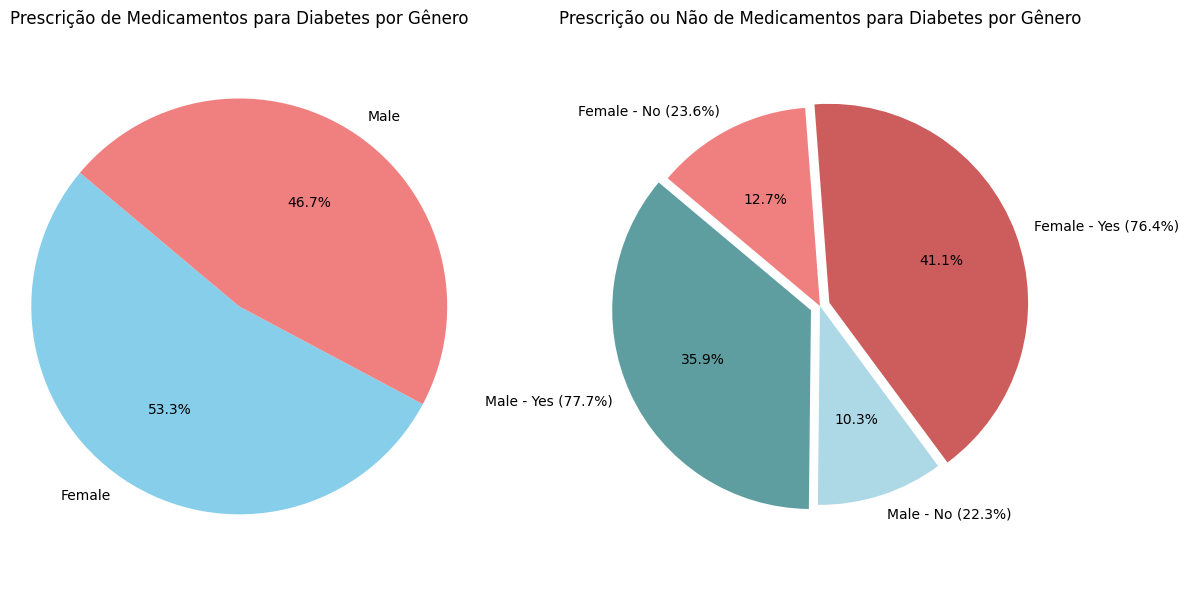

In [ ]:

# Filtrar dados para incluir apenas os gêneros 'Male' e 'Female' e excluir 'Invalid'
df_filtered_gender = dataset_copy[dataset_copy['gender'].isin(['Male', 'Female'])].copy()

# Contabilizar o número de diabéticos por gênero
diabetes_genero = df_filtered_gender[df_filtered_gender['diabetesMed'] == 'Yes']['gender'].value_counts()

# Contabilizar a distribuição geral por gênero
contagem_generoxdiabeticos = df_filtered_gender['gender'].value_counts()

# Preparar dados para o segundo gráfico de pizza (gênero x diabetes)
contagem_generoxdiabeticos = df_filtered_gender.groupby(['gender', 'diabetesMed']).size().unstack(fill_value=0)
contagem_generoxdiabeticos['Total'] = contagem_generoxdiabeticos.sum(axis=1)
contagem_generoxdiabeticos['% Yes'] = (contagem_generoxdiabeticos['Yes'] / contagem_generoxdiabeticos['Total']) * 100
contagem_generoxdiabeticos['% No'] = (contagem_generoxdiabeticos['No'] / contagem_generoxdiabeticos['Total']) * 100

# Criar figura e subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de Pizza 1: Número de Diabéticos por Gênero (excluindo 'Invalid')
axes[0].pie(diabetes_genero, labels=diabetes_genero.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
axes[0].set_title('Prescrição de Medicamentos para Diabetes por Gênero')
axes[0].axis('equal')

# Gráfico de Pizza 2: Distribuição por Gênero e Condição de Diabetes
# Vamos criar as fatias combinadas para este gráfico
labels = []
sizes = []
colors = []
explode = []

# Adicionar fatias para Male (Yes e No)
if 'Male' in contagem_generoxdiabeticos.index:
    labels.append(f'Male - Yes ({contagem_generoxdiabeticos.loc["Male", "% Yes"]:.1f}%)')
    sizes.append(contagem_generoxdiabeticos.loc['Male', 'Yes'])
    colors.append('cadetblue')
    explode.append(0.05) # Adiciona um leve destaque
    labels.append(f'Male - No ({contagem_generoxdiabeticos.loc["Male", "% No"]:.1f}%)')
    sizes.append(contagem_generoxdiabeticos.loc['Male', 'No'])
    colors.append('lightblue')
    explode.append(0) # Sem destaque

# Adicionar fatias para Female (Yes e No)
if 'Female' in contagem_generoxdiabeticos.index:
    labels.append(f'Female - Yes ({contagem_generoxdiabeticos.loc["Female", "% Yes"]:.1f}%)')
    sizes.append(contagem_generoxdiabeticos.loc['Female', 'Yes'])
    colors.append('indianred')
    explode.append(0.05) # Adiciona um leve destaque
    labels.append(f'Female - No ({contagem_generoxdiabeticos.loc["Female", "% No"]:.1f}%)')
    sizes.append(contagem_generoxdiabeticos.loc['Female', 'No'])
    colors.append('lightcoral')
    explode.append(0) # Sem destaque


axes[1].pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
axes[1].set_title('Prescrição ou Não de Medicamentos para Diabetes por Gênero')
axes[1].axis('equal')

plt.tight_layout()
print('Resumo das prescrições:')
print(contagem_generoxdiabeticos.to_markdown())
print('\n\n')

plt.show()


 Fica evidente que a maioria dos pacientes, tanto femininos quanto masculinos, recebeu prescrição de medicamentos para diabetes.

Para as **mulheres**, 76,38% (41.787 pacientes) tiveram algum medicamento para diabetes prescrito, enquanto 23,62% (12.921 pacientes) não tiveram.
Entre os **homens**, a porcentagem é ligeiramente maior, com 77,73% (36.574 pacientes) recebendo a prescrição, contra 22,27% (10.481 pacientes) que não receberam.

Apesar da leve diferença percentual, ambos os gêneros demonstram uma alta taxa de prescrição de medicamentos para diabetes, indicando que a condição é amplamente tratada com medicação.

### Pacientes por Faixa Etária e Gênero









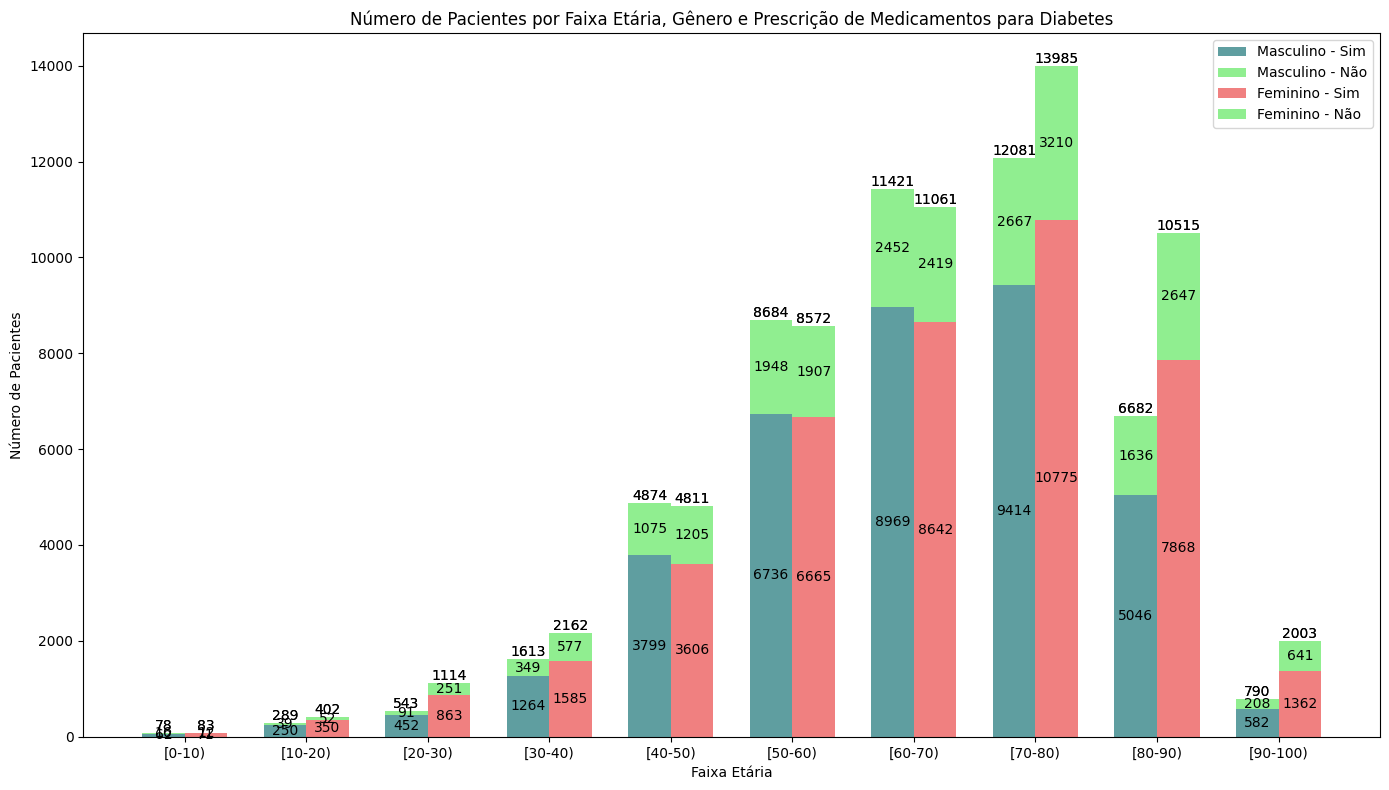

In [ ]:
# Agrupe os dados por faixa etária ('age'), gênero ('gender') e status de diabetes ('diabetesMed')
gender_age_diabetes = dataset_copy.groupby(['age', 'gender', 'diabetesMed']).size().unstack(fill_value=0)

# Cria o gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(14, 8))

# Largura das barras
bar_width = 0.35
index = np.arange(len(gender_age_diabetes.index.get_level_values('age').unique()))

# Posições das barras para cada gênero
male_positions = index
female_positions = index + bar_width

# Plota as barras empilhadas para 'Male'
bars_male_yes = ax.bar(male_positions, gender_age_diabetes.loc[(slice(None), 'Male'), 'Yes'], bar_width, label='Masculino - Sim', color='cadetblue')
bars_male_no = ax.bar(male_positions, gender_age_diabetes.loc[(slice(None), 'Male'), 'No'], bar_width, bottom=gender_age_diabetes.loc[(slice(None), 'Male'), 'Yes'], label='Masculino - Não', color='lightgreen') #lightblue

# Plota as barras empilhadas para 'Female'
bars_female_yes = ax.bar(female_positions, gender_age_diabetes.loc[(slice(None), 'Female'), 'Yes'], bar_width, label='Feminino - Sim', color='lightcoral')
bars_female_no = ax.bar(female_positions, gender_age_diabetes.loc[(slice(None), 'Female'), 'No'], bar_width, bottom=gender_age_diabetes.loc[(slice(None), 'Female'), 'Yes'], label='Feminino - Não', color='lightgreen') #lightsalmon

# Configurações do eixo X
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(gender_age_diabetes.index.get_level_values('age').unique())
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Número de Pacientes')
ax.set_title('Número de Pacientes por Faixa Etária, Gênero e Prescrição de Medicamentos para Diabetes')
ax.legend()

# Adiciona os valores no final das barras
def add_stacked_value_labels(ax, bars, total_values):
    for bar, total in zip(bars, total_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2,
                f'{int(height)}',
                ha='center', va='center')
    # Adiciona o total no topo da barra empilhada
    for i, bar in enumerate(bars):
        if i < len(total_values):
            ax.text(bar.get_x() + bar.get_width() / 2, total_values[i],
                    f'{int(total_values[i])}',
                    ha='center', va='bottom')


# Calcula os totais para adicionar os rótulos no topo das barras empilhadas
male_totals = gender_age_diabetes.loc[(slice(None), 'Male'), :].sum(axis=1).values
female_totals = gender_age_diabetes.loc[(slice(None), 'Female'), :].sum(axis=1).values

add_stacked_value_labels(ax, bars_male_yes, male_totals)
add_stacked_value_labels(ax, bars_male_no, male_totals)
add_stacked_value_labels(ax, bars_female_yes, female_totals)
add_stacked_value_labels(ax, bars_female_no, female_totals)

plt.tight_layout()
#print(gender_age_diabetes.to_markdown())
plt.show()


De forma geral, a análise reafirma o padrão já observado: a maioria dos pacientes, independentemente do gênero, recebe prescrição de medicamentos para diabetes, e essa proporção tende a aumentar com a idade. Na maioria das faixas etárias, a mulher tende a receber mais indicação de uso de medicação.

### Variação da Média de Prescrições de Medicamentos por Faixa Etária e Gênero

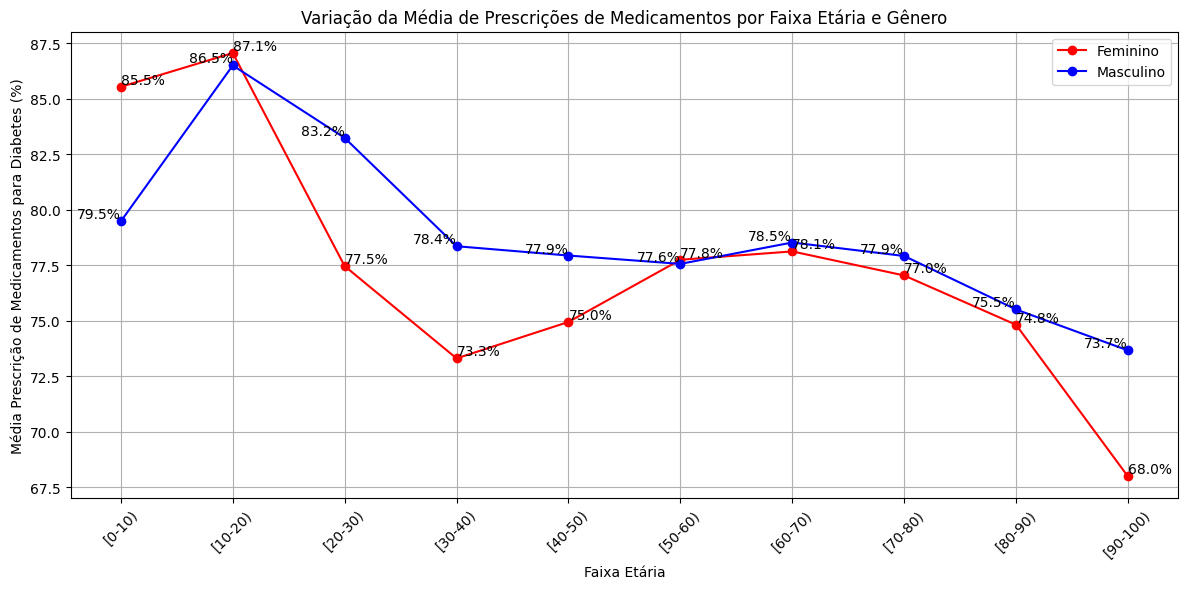

In [ ]:
plt.figure(figsize=(12, 6))

gender_age_diabetes = dataset_copy.groupby(['age', 'gender', 'diabetesMed']).size().unstack(fill_value=0)
df_result = gender_age_diabetes.copy()
df_result['Total'] = df_result['Yes'] + df_result['No']
df_result['Média Diabéticos (%)'] = (df_result['Yes'] / df_result['Total']) * 100

# nova coluna de porcentagem
df_female_diabetic = df_result.loc[(slice(None), 'Female'), :].reset_index()
df_male_diabetic = df_result.loc[(slice(None), 'Male'), :].reset_index()

# gráfico de linha para 'Female'
plt.plot(df_female_diabetic['age'], df_female_diabetic['Média Diabéticos (%)'], marker='o', linestyle='-', color='red', label='Feminino')#salmon

# gráfico de linha para 'Male'
plt.plot(df_male_diabetic['age'], df_male_diabetic['Média Diabéticos (%)'], marker='o', linestyle='-', color='blue', label='Masculino')

# Adiciona os valores das porcentagens no gráfico de linha
for age, row in df_female_diabetic.iterrows():
  plt.text(row['age'], row['Média Diabéticos (%)'], f'{row["Média Diabéticos (%)"]:.1f}%', color='black', ha="left", va="bottom")

for age, row in df_male_diabetic.iterrows():
  plt.text(row['age'], row['Média Diabéticos (%)'], f'{row["Média Diabéticos (%)"]:.1f}%', color='black', ha="right", va="bottom")


plt.xlabel('Faixa Etária')
plt.ylabel('Média Prescrição de Medicamentos para Diabetes (%)')
plt.title('Variação da Média de Prescrições de Medicamentos por Faixa Etária e Gênero')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
#print(df_result.to_markdown())
plt.show()

Analisando os valores absolutos, o gênero Feminino tende a ter uma maior incidência de prescrição de medicamentos em relação ao gênero masculino. Porém, quando esta análise é realizada pela média de prescrições, o resultado é invero.

## Tempo Médio de Internação por Faixa Etária

Resumo do tempo médio de internação (dias):
| age      |   time_in_hospital |
|:---------|-------------------:|
| [80-90)  |            4.80863 |
| [90-100) |            4.75582 |
| [70-80)  |            4.59088 |
| [60-70)  |            4.38224 |
| [50-60)  |            4.12575 |
| [40-50)  |            4.03965 |
| [30-40)  |            3.79974 |
| [20-30)  |            3.56488 |
| [10-20)  |            3.19103 |
| [0-10)   |            2.54658 |





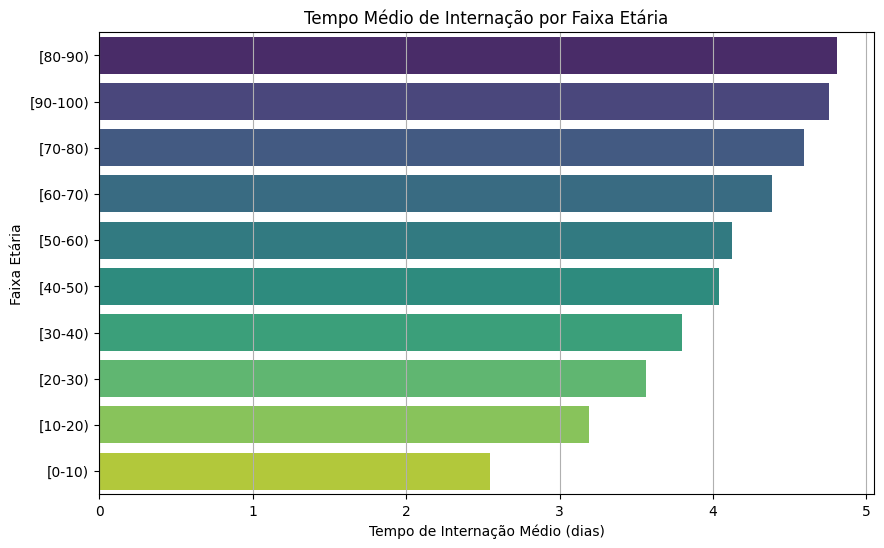

In [ ]:
# Calcula o tempo médio de internação por faixa etária
tempo_idade = dataset_copy.groupby('age')['time_in_hospital'].mean().reset_index()

# Ordena por tempo médio de internação para melhor visualização
tempo_idade = tempo_idade.sort_values('time_in_hospital', ascending=False)

# Cria o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
sns.barplot(x='time_in_hospital', y='age', data=tempo_idade, palette='viridis')
plt.xlabel('Tempo de Internação Médio (dias)')
plt.ylabel('Faixa Etária')
plt.title('Tempo Médio de Internação por Faixa Etária')
plt.grid(axis='x')

print('Resumo do tempo médio de internação (dias):')
print(tempo_idade.to_markdown(index=False))
print('\n\n')

plt.show()

Os dados demonstram a relação entre a idade do paciente e o tempo médio de internação hospitalar. Há uma tendência evidente de aumento do tempo de internação conforme a idade avança.

Essa análise sugere que pacientes mais velhos tendem a necessitar de cuidados hospitalares por períodos mais longos, o que pode ser atribuído a uma maior complexidade de condições de saúde, comorbidades ou um processo de recuperação mais lento em idades avançadas.

## Quantidade de consultas por Especialidades Médicas

In [ ]:

# Calcula a quantidade de cada especialidade médica
contagem_especialidades = dataset_copy['medical_specialty'].value_counts()

# Cria um DataFrame para exibir a tabela
total_especialidades = pd.DataFrame({'Especialidade Médica': contagem_especialidades.index, 'Número Total': contagem_especialidades.values})

# Ordena a tabela pela quantidade total em ordem decrescente
total_especialidades = total_especialidades.sort_values(by='Número Total', ascending=False).reset_index(drop=True)

# Exibe a tabela
print("Quantidade de pacientes por especialidade médica:")
total_especialidades

Quantidade de pacientes por especialidade médica:


,Especialidade Médica,Número Total
0,Not informed,49949
1,InternalMedicine,14635
2,Emergency/Trauma,7565
3,Family/GeneralPractice,7440
4,Cardiology,5352
...,...,...
68,Proctology,1
69,Speech,1
70,SportsMedicine,1
71,Perinatology,1


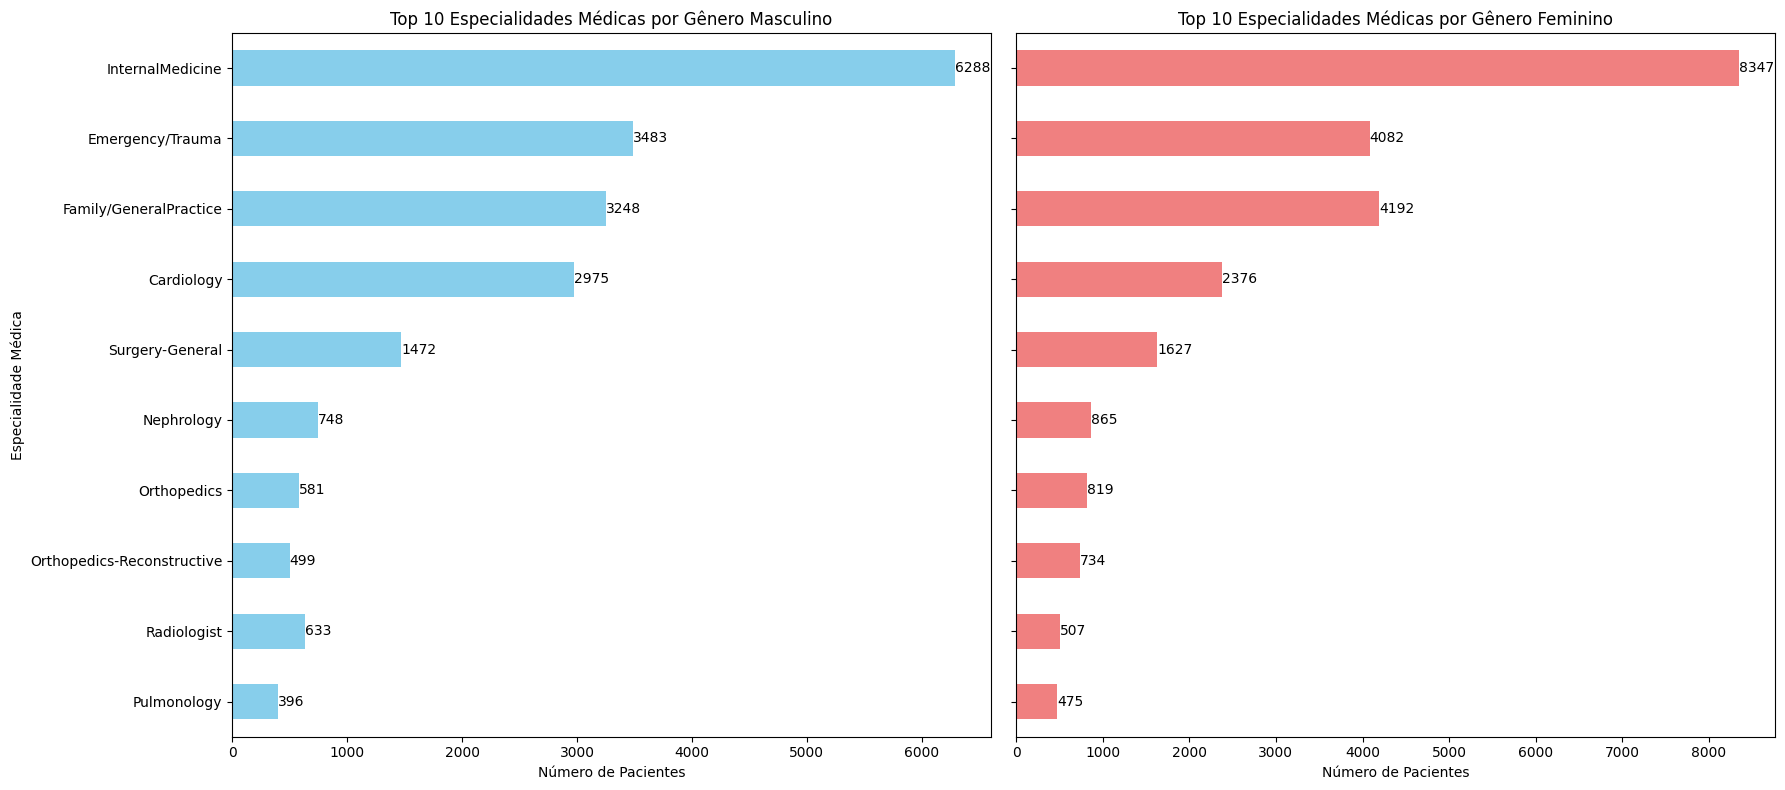

In [ ]:
# Filtra os dados para excluir 'Not informed' e 'Unknown/Invalid' do gênero
df_filtered = dataset_copy[(dataset_copy['medical_specialty'] != 'Not informed') &
                           (dataset_copy['gender'].isin(['Male', 'Female']))].copy()

# Conta as ocorrências das especialidades médicas por gênero e filtra as 10 mais frequentes
top_specialties = df_filtered['medical_specialty'].value_counts().nlargest(10).index
df_top_specialties = df_filtered[df_filtered['medical_specialty'].isin(top_specialties)]

# Agrupa os dados por especialidade e gênero, contando as ocorrências
especialidades_genero = df_top_specialties.groupby(['medical_specialty', 'gender']).size().unstack(fill_value=0)

# Reordena as especialidades para manter a ordem do top 6
especialidades_genero = especialidades_genero.loc[top_specialties]

# Cria os subplots para os dois gráficos
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Gráfico para Gênero Masculino
especialidades_genero['Male'].plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Especialidades Médicas por Gênero Masculino')
axes[0].set_xlabel('Número de Pacientes')
axes[0].set_ylabel('Especialidade Médica')
axes[0].invert_yaxis() # Inverte o eixo Y para ter a maior no topo
axes[0].tick_params(axis='y', which='major', labelsize=10) # Ajusta tamanho do tick do eixo y

# Adiciona os rótulos de valor nas barras
for i, v in enumerate(especialidades_genero['Male']):
    if v > 0:
        axes[0].text(v, i, str(v), va='center')

# Gráfico para Gênero Feminino
especialidades_genero['Female'].plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Top 10 Especialidades Médicas por Gênero Feminino')
axes[1].set_xlabel('Número de Pacientes')
axes[1].set_ylabel('') # Remove o rótulo do eixo Y no segundo gráfico para evitar redundância
axes[1].invert_yaxis() # Inverte o eixo Y para ter a maior no topo

# Adiciona os rótulos de valor nas barras
for i, v in enumerate(especialidades_genero['Female']):
     if v > 0:
        axes[1].text(v, i, str(v), va='center')


plt.tight_layout()
#print("Quantidade de pacientes por especialidade médica por gênero:")
#print(especialidades_genero.to_markdown())
plt.show()


Em resumo, a análise sugere que as mulheres tendem a buscar mais serviços em especialidades ligadas à atenção primária e cuidados gerais, enquanto os homens procuram mais especialidades como cardiologia.

## Atendimento de Emergência

### Pacientes por Faixa Etária

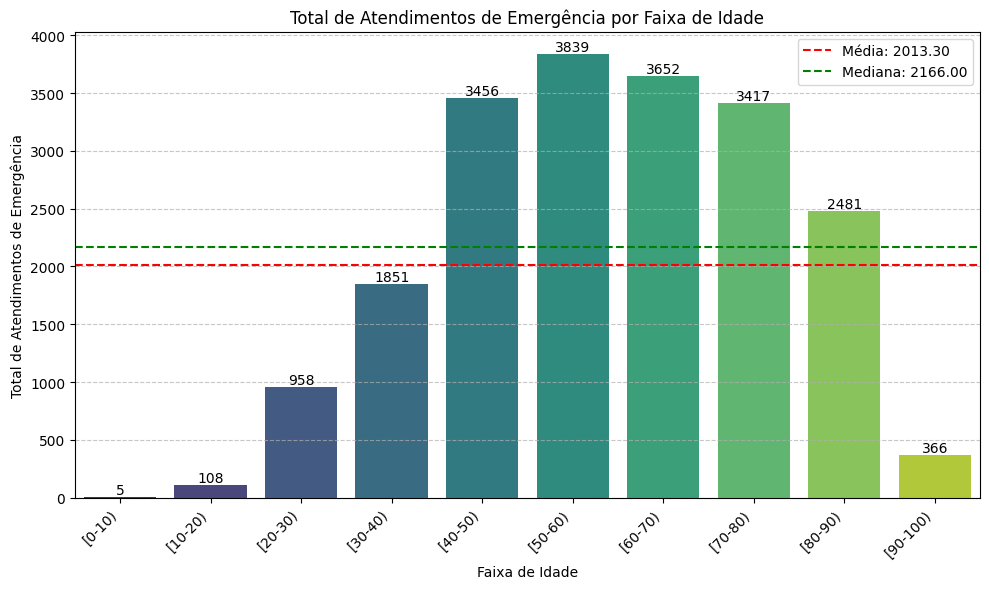

In [ ]:

# Agrupar os dados por faixa de idade e somar o número de atendimentos de emergência
emergency_by_age = dataset_copy.groupby('age')['number_emergency'].sum().reset_index()

# Ordenar as faixas etárias para exibição no gráfico (opcional, mas melhora a visualização)
# Assumindo que as faixas etárias estão no formato '[xx-yy)'
emergency_by_age['age_order'] = emergency_by_age['age'].apply(lambda x: int(x.split('-')[0].replace('[','')))
emergency_by_age = emergency_by_age.sort_values('age_order').drop('age_order', axis=1)

# Calcular a média e a mediana do número total de atendimentos de emergência
mean_emergency = dataset_copy['number_emergency'].sum() / len(dataset_copy['age'].unique()) # Média sobre o número de faixas de idade
median_emergency = emergency_by_age['number_emergency'].median()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='age', y='number_emergency', data=emergency_by_age, palette='viridis')
plt.title('Total de Atendimentos de Emergência por Faixa de Idade')
plt.xlabel('Faixa de Idade')
plt.ylabel('Total de Atendimentos de Emergência')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar a linha da média
plt.axhline(mean_emergency, color='red', linestyle='--', label=f'Média: {mean_emergency:.2f}')

# Adicionar a linha da mediana
plt.axhline(median_emergency, color='green', linestyle='--', label=f'Mediana: {median_emergency:.2f}')

plt.legend()
plt.tight_layout()

# Adicionar os valores totais em cada barra do gráfico
for index, row in emergency_by_age.iterrows():
    plt.text(index, row['number_emergency'], int(row['number_emergency']), color='black', ha="center", va='bottom')


plt.show()

#print("Total de Atendimentos de Emergência por Faixa de Idade:")
#print(emergency_by_age.to_markdown(index=False))


Os atendimentos de emergência aumentam progressivamente com a idade até atingir um pico em faixas etárias intermediárias a idosas (40 e 80), e então começam a diminuir nas idades mais avançadas.



### Pacientes por Gênero

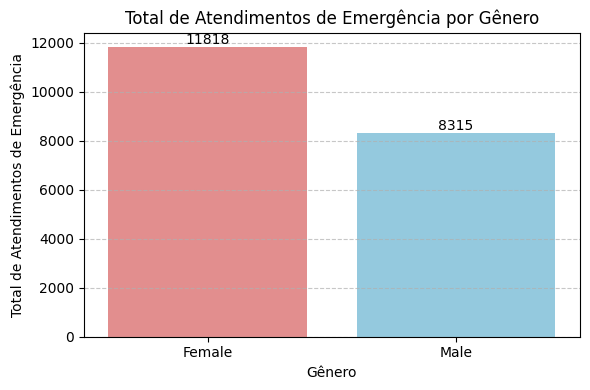

In [ ]:

# Agrupar os dados por gênero e somar o número de atendimentos de emergência
emergencia_genero = dataset_copy.groupby('gender')['number_emergency'].sum().reset_index()

# Remover a categoria 'Unknown/Invalid' se existir
emergencia_genero = emergencia_genero[emergencia_genero['gender'].isin(['Male', 'Female'])]

# Criar o gráfico de barras
plt.figure(figsize=(6, 4))
sns.barplot(x='gender', y='number_emergency', data=emergencia_genero, palette=['lightcoral', 'skyblue'])
plt.title('Total de Atendimentos de Emergência por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Total de Atendimentos de Emergência')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores totais em cada barra do gráfico
for index, row in emergencia_genero.iterrows():
    plt.text(index, row['number_emergency'], int(row['number_emergency']), color='black', ha="center", va='bottom')

plt.tight_layout()

#print("Total de Atendimentos de Emergência por Gênero:")
#print(emergencia_genero.to_markdown(index=False))

plt.show()

###Pacientes por Faixa Etária e Gênero

> Adicionar aspas



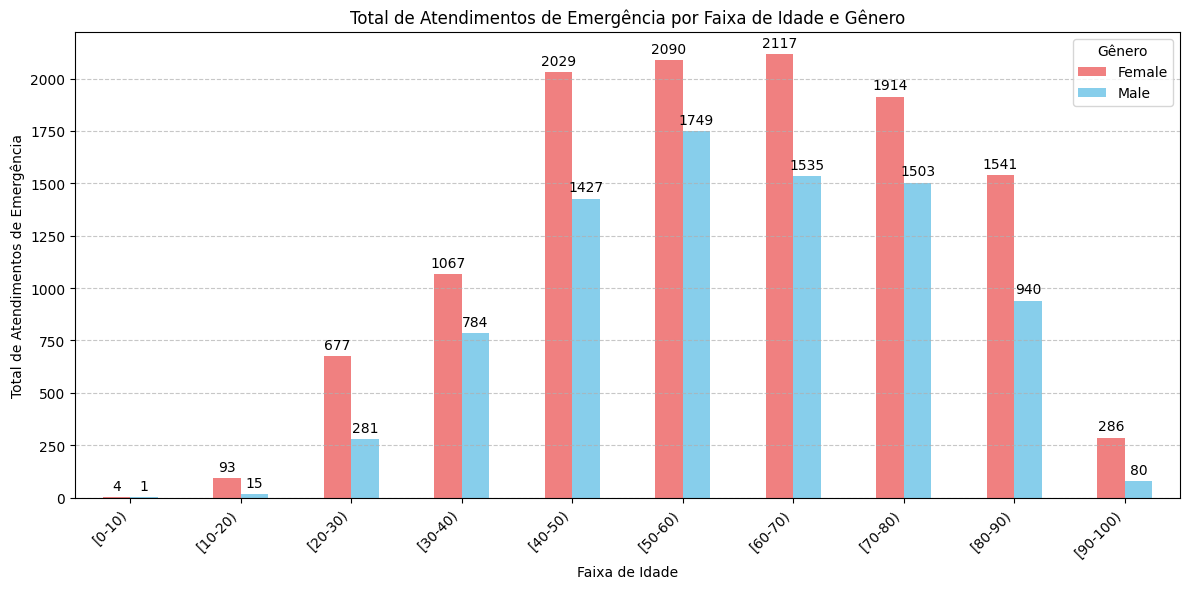

In [ ]:
# Agrupar os dados por faixa de idade e gênero, somando o número de atendimentos de emergência
emergencia_genero_idade = dataset_copy.groupby(['age', 'gender'])['number_emergency'].sum().unstack(fill_value=0)

# Ordenar as faixas etárias para exibição no gráfico (opcional, mas melhora a visualização)
# Assumindo que as faixas etárias estão no formato '[xx-yy)'
emergencia_genero_idade = emergencia_genero_idade.reset_index()
emergencia_genero_idade['age_order'] = emergencia_genero_idade['age'].apply(lambda x: int(x.split('-')[0].replace('[','')))
emergencia_genero_idade = emergencia_genero_idade.sort_values('age_order').drop('age_order', axis=1).set_index('age')

# Remover a categoria 'Unknown/Invalid' se existir
if 'Unknown/Invalid' in emergencia_genero_idade.columns:
    emergencia_genero_idade = emergencia_genero_idade.drop(columns=['Unknown/Invalid'])

# Criar o gráfico de barras duplas
ax = emergencia_genero_idade.plot(kind='bar', figsize=(12, 6), color=['lightcoral', 'skyblue'])

plt.title('Total de Atendimentos de Emergência por Faixa de Idade e Gênero')
plt.xlabel('Faixa de Idade')
plt.ylabel('Total de Atendimentos de Emergência')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gênero')

# Adicionar os valores totais em cada barra do gráfico
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

#print("Total de Atendimentos de Emergência por Faixa de Idade e Gênero:")
#print(emergencia_genero_idade.to_markdown())


Em todas as faixas de idade, as consultas em emergências são predominantes em mulheres.